# Neural Style Transfer (Gatys et al., 2015) — PyTorch Implementation

## 1. What is Neural Style Transfer?

Neural Style Transfer (NST) combines two images:
- A **content image** (e.g., a photo) — provides the "what" (objects, layout, structure).
- A **style image** (e.g., a painting) — provides the "how it looks" (colors, textures, brush strokes).

The output is a new image that has the **content** of the first and the **style** of the second.

Key idea: we don't train a neural network in the usual sense. Instead, we start with a copy
of the content image and use a pretrained CNN to iteratively **update its pixels** until it
simultaneously matches the content features of the content image and the style features of
the style image. Think of it as "editing an image using gradient descent" rather than
"training a model to predict something."

## 2. Why VGG19 as a Feature Extractor?

VGG19 is a deep CNN pretrained on ImageNet (1.4M images, 1000 classes). We don't use it to
classify anything here — we reuse its learned filters as a way to describe image content.

Why VGG19 specifically?
- Its layers form a hierarchy: **early layers** detect low-level features (edges, colors,
  simple textures), and **deeper layers** detect high-level features (object parts, shapes).
- This hierarchy happens to separate "content" (which lives more in deeper layers, since it's
  about structure/objects) from "style" (which lives across multiple layers, since it's about
  textures/patterns at many scales).
- It has a simple, uniform architecture (stacked 3x3 convolutions), which makes it easy to
  pick specific layers to extract features from.

We **freeze** VGG19's weights — we never update them. Only the pixels of our output image
get updated. This is why NST is often called an *optimization* problem rather than *training*.

## 3. Content Loss

We pick one deep layer of VGG19 (commonly `conv4_2`) and pass both the content image and the
current generated image through the network up to that layer, giving feature maps
$F^{content}$ and $F^{generated}$.

Content loss is simply the Mean Squared Error between these feature maps:

$$
L_{content}(C, G) = \frac{1}{2} \sum_{i,j} \left( F^{G}_{ij} - F^{C}_{ij} \right)^2
$$

Where:
- $C$ = content image, $G$ = generated image
- $F^C_{ij}$, $F^G_{ij}$ = activation of filter $i$ at position $j$ in the chosen layer

Minimizing this pushes the generated image's deep-layer activations to match the content
image's — i.e., it keeps the same objects/structure.

## 4. Gram Matrix and Style Loss

Style is about **correlations between filters**, not their exact spatial positions. Two
regions of a Van Gogh painting can have completely different brush strokes at different
locations but still "look like the same style" — because the same combinations of features
(color patterns, stroke textures) show up together, regardless of position.

The **Gram matrix** captures exactly this: for a layer with feature maps flattened to shape
$(N, M)$ (N = number of filters, M = height×width), the Gram matrix is:

$$
G_{ij} = \sum_{k} F_{ik} F_{jk}
$$

This is just the feature map matrix multiplied by its own transpose: $G = F F^T$. Each entry
$G_{ij}$ tells us how much filter $i$ and filter $j$ activate together across the whole image
— a compact summary of "texture style" with no spatial information.

Style loss compares the Gram matrices of the style image and generated image, at **multiple**
layers (unlike content loss, which uses one layer):

$$
L_{style} = \sum_{l} w_l \cdot \frac{1}{4 N_l^2 M_l^2} \sum_{i,j} \left( G^{G}_{l,ij} - G^{S}_{l,ij} \right)^2
$$

Where $l$ ranges over the chosen style layers, $w_l$ is a weight per layer (often equal),
and $N_l$, $M_l$ are that layer's filter count and spatial size (used for normalization).

## 5. Total Loss

The final loss is a weighted sum of content and style loss:

$$
L_{total} = \alpha \cdot L_{content} + \beta \cdot L_{style}
$$

- $\alpha$ controls how strongly content structure is preserved.
- $\beta$ controls how strongly the style pattern is applied.

In practice, $\beta \gg \alpha$ (e.g., $\alpha = 1$, $\beta = 10^6$) because raw style loss
values (summed Gram matrix differences across many filters) are numerically much larger than
content loss values — the huge ratio is mostly about balancing scale, not "style mattering a
million times more" conceptually.

## 6. Why Optimize Pixels, Not Network Weights?

In normal deep learning, we fix the input/output data and update the network's weights to
reduce a loss. Here we do the **opposite**:

- VGG19's weights are **frozen** — they already know how to extract good features; we don't
  want to change them.
- The **generated image's pixel values** are treated as the trainable parameters.
- We compute gradients of the total loss **with respect to the image pixels**, and update the
  pixels directly via gradient descent (`generated_image.requires_grad = True`).

So instead of "network learns from data," it's "one specific image is sculpted, pixel by
pixel, to satisfy two competing objectives."

## 7. Optimizer: L-BFGS (vs. Adam)

We use **L-BFGS**, a quasi-Newton optimizer, instead of the Adam optimizer typically used in
deep learning training.

Why L-BFGS here?
- We're optimizing a relatively small number of parameters (just one image's pixels) with a
  well-behaved, smooth loss surface — L-BFGS handles this kind of problem faster and more
  precisely than first-order methods like Adam.
- It uses second-order curvature information (approximated), so it converges in fewer
  iterations for this specific type of image-optimization problem.
- Adam works too (and is simpler to reason about / more forgiving of loss-scale issues) —
  it's a completely valid alternative, just usually needs more iterations for comparable
  quality. We'll use L-BFGS since it's what the original paper uses, but the code notes where
  you could swap in Adam.

# Imports

In [ ]:
# Used to work with tensors and run deep learning models
import torch

 # Provides tools to build neural network layers
import torch.nn as nn

# Used to update the model and reduce errors
import torch.optim as optim

# Provides ready-made models and image processing tools
from torchvision import models, transforms

In [ ]:
# Used to open and work with images
from PIL import Image

 # Used to display images and results
import matplotlib.pyplot as plt

# Used to make a separate copy of the model
import copy

# Setting GPU

In [ ]:
print(torch.cuda.is_available())

True


In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


# Load the Dataset

First extract the ZIP

In [ ]:
import zipfile

zip_path = "/content/NST_dataset.zip"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall("/content/")

Check the extracted folder

In [ ]:
import os

dataset_path = "/content/NST_dataset"

print("Dataset contents:")
print(os.listdir(dataset_path))

Dataset contents:
['Style_data', 'Content_data']


Set the correct paths

In [ ]:
content_path = "/content/NST_dataset/Content_data"
style_path = "/content/NST_dataset/Style_data"

print("Content images:", len(os.listdir(content_path)))
print("Style images:", len(os.listdir(style_path)))

Content images: 11
Style images: 19


# Image loading

### **Image -> Tensor**

In [ ]:
# Image size used for resizing all images
IMG_SIZE = 256

ImageNet normalization values

In [ ]:
# Mean and standard deviation used when VGG19 was trained
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]


# Mean tells us the average, and STD tells us how spread out the values are.

Create image preprocessing pipeline

In [ ]:
# Define the steps used to prepare an image before giving it to VGG19

# (transforms.Compose) - combine multiple image-processing steps into one pipeline.
loader = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),  # Resize image to 256x256
    transforms.ToTensor(),                    # Convert image into a PyTorch tensor
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)  # Normalize image values
])

Normalized = (Pixel - Mean) / Standard Deviation

Create the image loading function

In [ ]:
def load_image(path):
    # Open the image and make sure it has 3 color channels
    image = Image.open(path).convert('RGB')

    # Apply preprocessing and add a batch dimension
    image = loader(image).unsqueeze(0)

    # Move the image to GPU or CPU
    return image.to(device, torch.float)

Adds a batch dimension: [3, H, W] → [1, 3, H, W]
**`[Batch, Channels, Height, Width]`**

- **1 → Batch size:** We are processing 1 image at a time.
- **3 → Channels:** The image has 3 RGB channels (Red, Green, Blue).
- **H → Height:** Number of pixels from top to bottom.
- **W → Width:** Number of pixels from left to right.

Create function to display images

### **Tensor -> Image**

In [ ]:
def imshow(tensor, title=None):
    # Move tensor to CPU and remove the batch dimension
    image = tensor.cpu().clone().squeeze(0)

    # Undo ImageNet normalization
    for c, m, s in zip(range(3), IMAGENET_MEAN, IMAGENET_STD):
        image[c] = image[c] * s + m

    # Keep pixel values between 0 and 1
    image = image.clamp(0, 1)

    # Convert tensor back to an image
    image = transforms.ToPILImage()(image)

    # Display the image
    plt.imshow(image)

    # Show title if provided
    if title:
        plt.title(title)

    plt.axis('off')

Pixel = Normalized × STD + Mean

**Displaying the Image**

The **`imshow()`** function is used to convert the processed tensor back into a normal image so that we can see it.

The neural network works with tensors, but humans cannot easily understand tensor values. Therefore, before displaying the image, we:

1. Move the tensor from GPU to CPU.
2. Remove the batch dimension `[1, 3, H, W] → [3, H, W]`.
3. Undo ImageNet normalization.
4. Keep pixel values between 0 and 1.
5. Convert the tensor into a PIL image.
6. Display the image using Matplotlib.

Test with your dataset

In [ ]:
content_files = os.listdir(content_path)
style_files = os.listdir(style_path)

In [ ]:
# Get the first content and style image
content_file = content_files[0]
style_file = style_files[0]

# Create complete paths
content_image_path = os.path.join(content_path, content_file)
style_image_path = os.path.join(style_path, style_file)

print("Content:", content_image_path)
print("Style:", style_image_path)

Content: /content/NST_dataset/Content_data/newyork.jpg
Style: /content/NST_dataset/Style_data/the_resevoir_at_poitiers.jpg


Load both images

In [ ]:
# Load and preprocess the content image
content = load_image(content_image_path)

# Load and preprocess the style image
style = load_image(style_image_path)

print("Content shape:", content.shape)
print("Style shape:", style.shape)
print("Device:", content.device)

Content shape: torch.Size([1, 3, 256, 256])
Style shape: torch.Size([1, 3, 256, 256])
Device: cuda:0


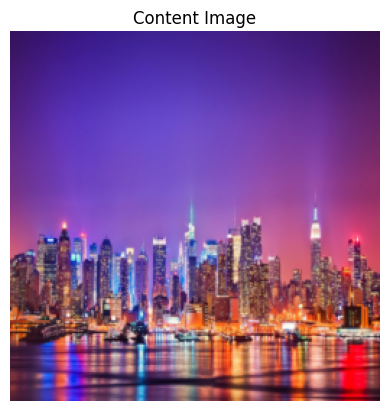

In [ ]:
# Display the content image
imshow(content, "Content Image")

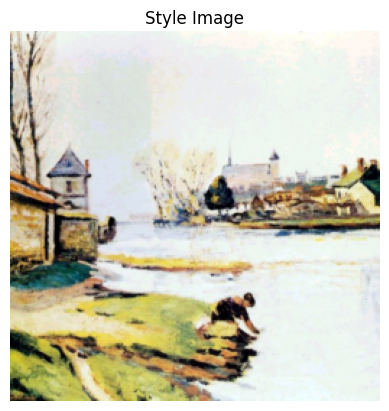

In [ ]:
# Display the style image
imshow(style, "Style Image")

# Load frozen VGG19

In [ ]:
# Create a VGG19 model using the pretrained ImageNet-1K weights and store that model in the variable vgg
vgg = models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)

print("VGG19 loaded successfully")

VGG19 loaded successfully


**What are we doing?**
VGG19 is a pretrained Convolutional Neural Network (CNN).

We use it as a **feature extractor** in Neural Style Transfer.

We will:
1. Load the pretrained VGG19 model.
2. Keep only its feature extraction layers.
3. Move the model to GPU.
4. Set it to evaluation mode.
5. Freeze its weights because we do not want to train VGG19.

**Why use pretrained weights?**

Training a CNN from the beginning requires a large dataset and a lot of time.

VGG19 has already learned useful visual patterns from ImageNet, such as:
- Edges
- Shapes
- Textures
- Object patterns

We reuse this knowledge to extract features from our content and style images.

In [ ]:
# Keep only the convolutional feature extraction layers
print(vgg)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (17): ReLU(inplace=True)
  (18): MaxPoo

In [ ]:
# Move VGG19 to the selected device (GPU if available)
vgg = vgg.to(device)

print("VGG19 device:", next(vgg.parameters()).device)

VGG19 device: cuda:0


In [ ]:
# Freeze all VGG19 parameters so its weights do not change
for param in vgg.parameters():
    param.requires_grad = False


**requires_grad** - Don't calculate gradients for VGG19's weights because we don't want to train VGG19

**Choosing Layers for Content and Style**

Following the original paper's common setup:
- **Content layer**: `conv4_2` — deep enough to capture structure, not just raw pixels.
- **Style layers**: `conv1_1, conv2_1, conv3_1, conv4_1, conv5_1` — one early layer from each
  block, so style is captured at multiple scales (fine textures to broad patterns).

VGG19's layers are indexed numerically in PyTorch's `features` module, so we map the names
above to their index numbers.

In [ ]:
# Map VGG19 layer numbers to readable names
layer_map = {
    '0': 'conv1_1',
    '5': 'conv2_1',
    '10': 'conv3_1',
    '19': 'conv4_1',
    '21': 'conv4_2',
    '28': 'conv5_1'
}

# Layer used to represent image content
content_layer = 'conv4_2'

# Layers used to represent image style
style_layers = [
    'conv1_1',
    'conv2_1',
    'conv3_1',
    'conv4_1',
    'conv5_1'
]


def get_features(image, model, layers):
    # Store the selected layer outputs
    features = {}

    # Start with the input image
    x = image

    # Pass the image through VGG19 layer by layer
    for name, layer in model._modules.items():

        # Get the output of the current layer
        x = layer(x)

        # Save the output if this is a selected layer
        if name in layer_map:
            features[layer_map[name]] = x

    return features

image → the image we want to analyze

model → VGG19

layers → layers we want to collect

Early layers → simple features such as edges and colors.

Middle layers → shapes and textures.

Deeper layers → more complex structures and content.

**conv4_2**

conv → convolutional layer

4    → VGG19 block 4

2    → second convolution in that block

## Defining the Loss Functions

- `gram_matrix`: computes the Gram matrix for a given feature map (used for style loss).
- `content_loss`: MSE between generated and content feature maps at `conv4_2`.
- `style_loss`: sum of MSE between Gram matrices at each style layer.

In [56]:
def gram_matrix(tensor):
    # Get batch size, channels, height, and width
    b, c, h, w = tensor.size()

    # Flatten height and width into one dimension
    features = tensor.view(c, h * w)

    # Measure relationships between feature channels
    gram = torch.mm(features, features.t())

    # Normalize the Gram Matrix
    return gram / (c * h * w)

In [57]:
def compute_content_loss(gen_features, content_features):
    # Compare generated and original content features
    difference = gen_features[content_layer] - content_features[content_layer]

    # Calculate the average squared difference
    return torch.mean(difference ** 2)

In [58]:
def compute_style_loss(gen_features, style_grams):
    # Start with zero style loss
    loss = 0

    # Compare style at each selected VGG19 layer
    for layer in style_layers:

        # Calculate Gram Matrix of generated image
        gen_gram = gram_matrix(gen_features[layer])

        # Get Gram Matrix of the target style image
        style_gram = style_grams[layer]

        # Add the difference for this layer to total loss
        loss += torch.mean((gen_gram - style_gram) ** 2)

    return loss

**compute_content_loss()** → checks whether the generated image keeps the content of the original image.

**compute_style_loss()** → checks whether the generated image has the style of the style image.

**gram_matrix()** → helps us measure the style.

Load the content and style images

In [61]:
# Get the first content and style image paths
content_image_path = os.path.join(content_path, content_files[0])
style_image_path = os.path.join(style_path, style_files[0])

Convert images into tensors

In [62]:
# Load and preprocess the content image
content_img = load_image(content_image_path)

# Load and preprocess the style image
style_img = load_image(style_image_path)

print("Content image shape:", content_img.shape)
print("Style image shape:", style_img.shape)

Content image shape: torch.Size([1, 3, 256, 256])
Style image shape: torch.Size([1, 3, 256, 256])


Extract content features

In [63]:
# Extract selected VGG19 features from the content image
content_features = get_features(content_img, vgg, layer_map)

print("Content features extracted")

Content features extracted


In [64]:
content_features = get_features(content_img, vgg, layer_map)
style_features = get_features(style_img, vgg, layer_map)

# Precompute Gram matrices for the style image (fixed targets, computed once)
style_grams = {layer: gram_matrix(style_features[layer]) for layer in style_layers}

# Initialize generated image as a copy of the content image
generated_img = content_img.clone().requires_grad_(True)

## **Optimizer and loss weights**

Set content and style weights

In [65]:
# Weight given to the content loss
alpha = 1

# Weight given to the style loss
beta = 1e6

Total Loss = alpha × Content Loss + beta × Style Loss

alpha = 1

beta = 1,000,000

we are giving the style loss a much larger weight.

Why?

Because the numerical values of content loss and style loss can have very different scales. Without balancing them, one loss might have very little effect on the optimization.

Create the optimizer

In [66]:
# Create an optimizer that will update the generated image
optimizer = optim.LBFGS([generated_img])

### Why do we use LBFGS?

LBFGS is an optimization algorithm that changes the generated image to reduce the total loss.

Unlike normal model training, we are not updating VGG19 weights.

We are directly updating the pixels of the generated image.

LBFGS is commonly used for optimization-based Neural Style Transfer.

Optional Adam optimizer

LBFGS → often fewer optimization steps

Adam  → simpler and commonly used, but may need more steps

In [67]:
# Number of times we optimize the generated image
num_steps = 300

In [68]:
# Counter used to keep track of optimization steps
run = [0]

## Content Loss

Content loss measures how different the generated image is from the original content image.

We compare their feature representations from the selected content layer (`conv4_2`).

### Formula

\[
L_{content} =
\frac{1}{N}
\sum_{i=1}^{N}
\left(F_{generated,i} - F_{content,i}\right)^2
\]

Where:

- \(F_{generated}\) = features of the generated image
- \(F_{content}\) = features of the original content image
- (N\) = total number of feature values

In simple words:

**Content Loss = Average squared difference between generated and content features.**

A smaller content loss means the generated image keeps more of the original content.

## **The optimization loop**

In [ ]:
print("Starting optimization...")

# Repeat the optimization until the required number of steps is reached
while run[0] <= num_steps:

**Why closure?**

LBFGS needs a function that calculates the loss and its gradients. It may call this function multiple times during one optimization step.

In [75]:
def closure():
    # Remove gradients from the previous calculation
    optimizer.zero_grad()

    # Extract features from the current generated image
    gen_features = get_features(generated_img, vgg, layer_map)

    # Calculate how much the generated image differs in content
    c_loss = compute_content_loss(gen_features, content_features)

    # Calculate how much the generated image differs in style
    s_loss = compute_style_loss(gen_features, style_grams)

    # Combine content loss and style loss
    total_loss = alpha * c_loss + beta * s_loss

    # Calculate gradients with respect to the generated image
    total_loss.backward()

    # Increase the optimization step counter
    run[0] += 1

    # Display the losses after every 50 steps
    if run[0] % 50 == 0:
        print(f"Step {run[0]}: Content Loss={c_loss.item():.4f}, "
              f"Style Loss={s_loss.item():.6f}, Total Loss={total_loss.item():.4f}")

    return total_loss


# Training loop: keep calling optimizer.step(closure) until we hit num_steps
print("Starting optimization...")

while run[0] <= num_steps:
    optimizer.step(closure)

print("Optimization complete.")

Starting optimization...
Step 50: Content Loss=5.9426, Style Loss=0.000009, Total Loss=14.7921
Step 100: Content Loss=5.3143, Style Loss=0.000007, Total Loss=12.1167
Step 150: Content Loss=5.0640, Style Loss=0.000006, Total Loss=11.1681
Step 200: Content Loss=4.9106, Style Loss=0.000006, Total Loss=10.5678
Step 250: Content Loss=4.8076, Style Loss=0.000005, Total Loss=10.0858
Step 300: Content Loss=4.7430, Style Loss=0.000005, Total Loss=9.6758
Optimization complete.


# **Display results**

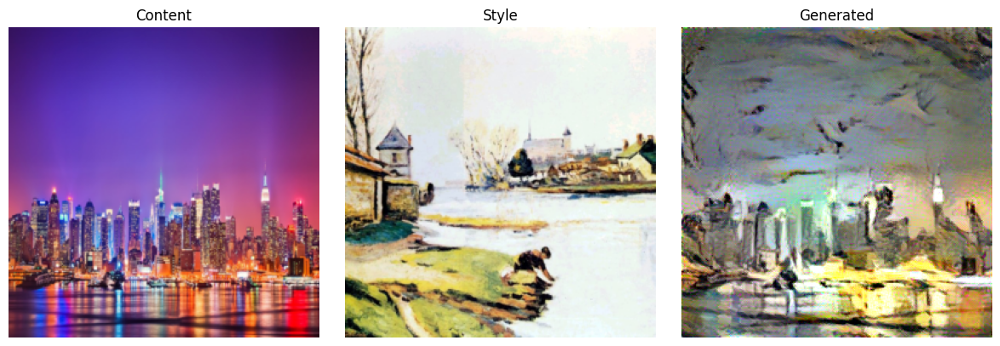

In [76]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
imshow(content_img, title="Content")

plt.subplot(1, 3, 2)
imshow(style_img, title="Style")

plt.subplot(1, 3, 3)
imshow(generated_img, title="Generated")

plt.tight_layout()
plt.show()

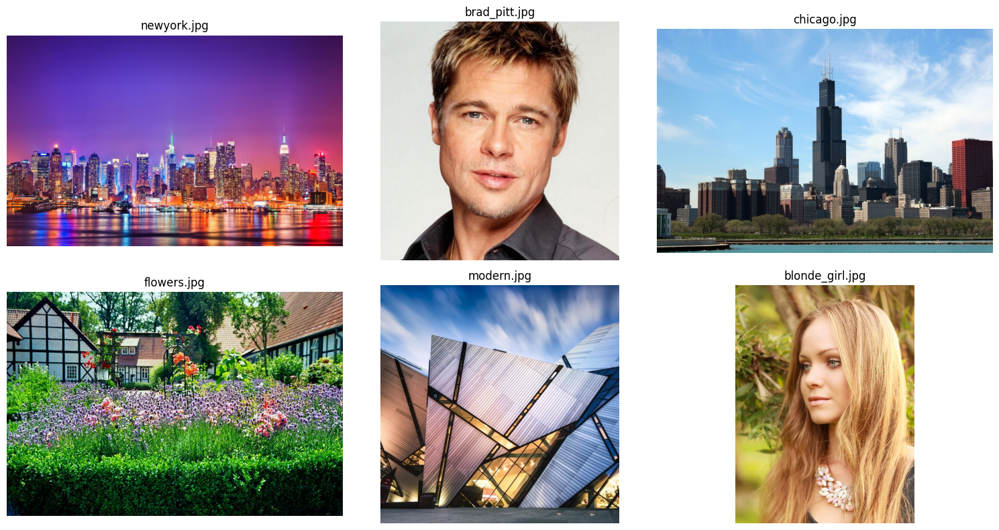

In [77]:
# Display the first 6 content images

plt.figure(figsize=(15, 8))

for i in range(6):
    image_path = os.path.join(content_path, content_files[i])
    image = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(content_files[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

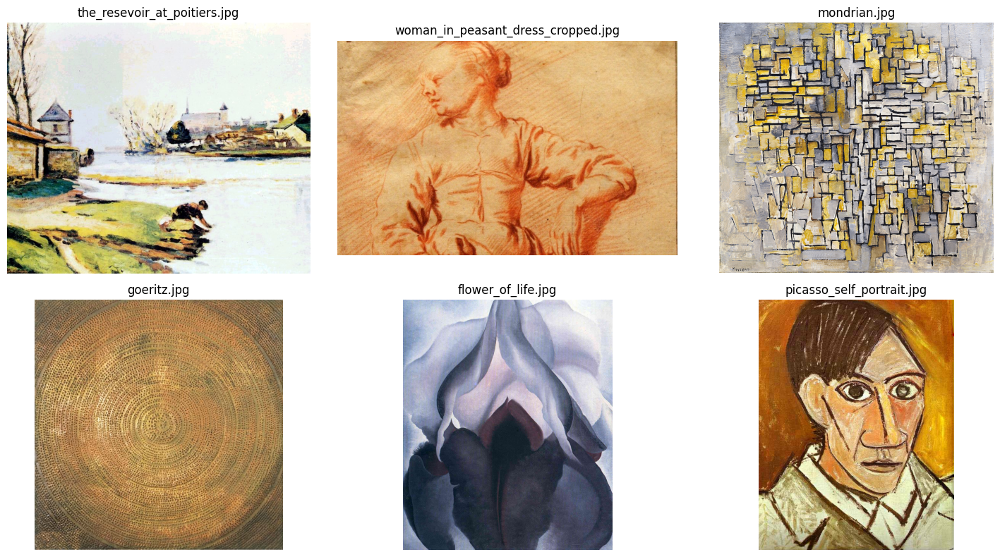

In [78]:
# Display the first 6 style images

plt.figure(figsize=(15, 8))

for i in range(6):
    image_path = os.path.join(style_path, style_files[i])
    image = Image.open(image_path).convert("RGB")

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(style_files[i])
    plt.axis("off")

plt.tight_layout()
plt.show()

In [80]:
# Store the generated images
generated_results = []

# Generate results for 6 content-style pairs
for i in range(6):

    print(f"Generating image {i + 1}/6...")

    # Select content and style images
    content_image_path = os.path.join(content_path, content_files[i])
    style_image_path = os.path.join(style_path, style_files[i])

    # Load the images
    content_img = load_image(content_image_path)
    style_img = load_image(style_image_path)

    # Extract content and style features
    with torch.no_grad():
        content_features = get_features(content_img, vgg, layer_map)
        style_features = get_features(style_img, vgg, layer_map)

    # Calculate Gram Matrices for the style image
    style_grams = {}

    for layer in style_layers:
        style_grams[layer] = gram_matrix(style_features[layer])

    # Start generated image from the content image
    generated_img = content_img.clone()
    generated_img.requires_grad_(True)

    # Create a new optimizer for this image
    optimizer = optim.LBFGS([generated_img])

    # Counter for this image
    run = [0]

    # Number of optimization steps
    num_steps = 300

    # Define the LBFGS closure
    def closure():
        optimizer.zero_grad()

        # Extract features from generated image
        gen_features = get_features(generated_img, vgg, layer_map)

        # Calculate content and style losses
        c_loss = compute_content_loss(
            gen_features,
            content_features
        )

        s_loss = compute_style_loss(
            gen_features,
            style_grams
        )

        # Calculate total loss
        total_loss = alpha * c_loss + beta * s_loss

        # Calculate gradients
        total_loss.backward()

        run[0] += 1

        return total_loss

    # Run optimization
    while run[0] <= num_steps:
        optimizer.step(closure)

    # Save the generated image
    generated_results.append(generated_img.detach().clone())

    print(f"Image {i + 1} completed.")

print("All 6 images generated successfully!")

Generating image 1/6...
Image 1 completed.
Generating image 2/6...
Image 2 completed.
Generating image 3/6...
Image 3 completed.
Generating image 4/6...
Image 4 completed.
Generating image 5/6...
Image 5 completed.
Generating image 6/6...
Image 6 completed.
All 6 images generated successfully!


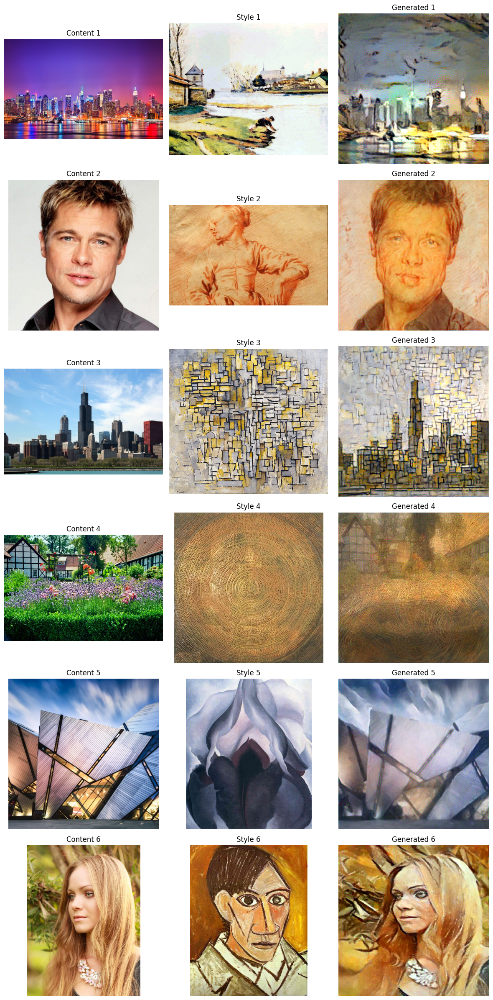

In [81]:
# Display 6 content + style + generated results

plt.figure(figsize=(12, 24))

for i in range(6):

    # Load content image for display
    content_image_path = os.path.join(content_path, content_files[i])
    content_display = Image.open(content_image_path).convert("RGB")

    # Load style image for display
    style_image_path = os.path.join(style_path, style_files[i])
    style_display = Image.open(style_image_path).convert("RGB")

    # Content
    plt.subplot(6, 3, i * 3 + 1)
    plt.imshow(content_display)
    plt.title(f"Content {i + 1}")
    plt.axis("off")

    # Style
    plt.subplot(6, 3, i * 3 + 2)
    plt.imshow(style_display)
    plt.title(f"Style {i + 1}")
    plt.axis("off")

    # Generated
    plt.subplot(6, 3, i * 3 + 3)
    imshow(generated_results[i], title=f"Generated {i + 1}")

plt.tight_layout()
plt.show()